# What we will learn?
- Simple linear regression
- Python packages
- First regression model

# Python Packages
- Numpy
- Pandas
- Scipy 
- Skilearn
- Matplotlib
- Statsmodel
- Seaborn

# Linear Regression

Linear regression helps us understand the relationship between the dependent variable and one or more independent variables by fitting a linear equation to the observed data.
$$
{Y_i} = \beta_0 + \beta_1{X_i}
$$

${Y_i}$ = Dependent variable,
${\beta_0}$ = Constant/Intercept,
${\beta_1}$ = Slope/Coefficient,
${X_i}$ = Independent Variable.

In [70]:
#import all the important packages
#!pip install seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
sns.set()

# Load the data

In [82]:
data=pd.read_csv('SimpleData.csv')
data

,SAT Score,GPA
0,1600,4.0
1,1593,4.0
2,1587,4.0
3,1580,4.0
4,1573,4.0
...,...,...
176,427,0.0
177,420,0.0
178,413,0.0
179,407,0.0


In [83]:
data.describe()

,SAT Score,GPA
count,181.000000,181.000000
mean,1000.000000,2.617901
std,349.293573,1.559243
min,400.000000,0.000000
25%,700.000000,1.390000
50%,1000.000000,3.370000
75%,1300.000000,3.970000
max,1600.000000,4.000000


# First Regression

Define the dependent and independent variable

In [84]:
# y is the dependent variable
# x is the independent variable
y=data['GPA']
x1=data['SAT Score']

## Explore the data

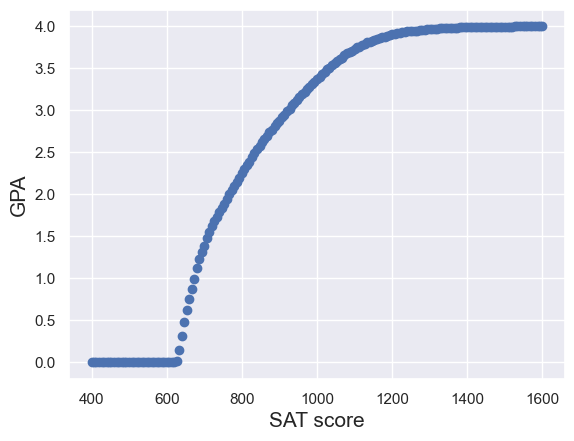

In [85]:
plt.scatter(x1,y)
plt.xlabel('SAT score', fontsize=15)
plt.ylabel('GPA', fontsize=15)
plt.show()

In [86]:
x = sm.add_constant(x1)
result = sm.OLS(y,x).fit() #OLS = Ordinary least square
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     1031.
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           3.40e-76
Time:                        13:05:36   Log-Likelihood:                -163.78
No. Observations:                 181   AIC:                             331.6
Df Residuals:                     179   BIC:                             338.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5027      0.136    -11.058      0.000      -1.771      -1.235
SAT Score      0.0041      0.000     32.109      0.000       0.004       0.004
==============================================================================
Omnibus:                      229.872   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               15.674
Skew:                          -0.244   Prob(JB):                     0.000395
Kurtosis:                       1.644   Cond. No.                     3.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

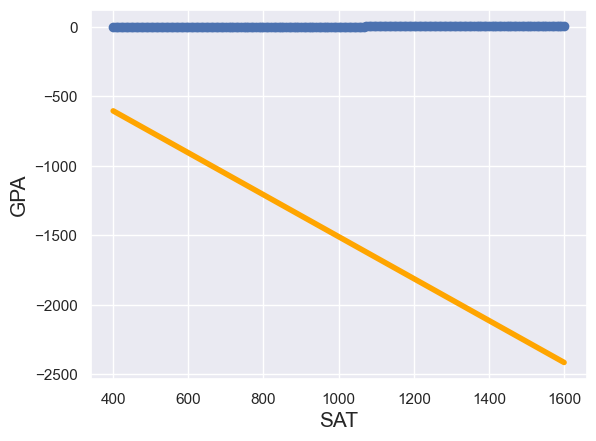

In [88]:
plt.scatter(x1,y)
yhat = -1.51*x1+(0.0041)
fig = plt.plot(x1,yhat,lw=4, c='orange',label='regression line')
plt.xlabel('SAT', fontsize=15)
plt.ylabel('GPA', fontsize=15)
plt.show()

In [ ]:
new_data = pd.DataFrame({'const':1,'SAT':[1700,1670]})
new_data = new_data[['const','SAT']]
new_data

In [65]:
new_data.rename(index={0:'Bob',1:'Alice'})

,const,SAT
Bob,1,1700
Alice,1,1670


In [89]:
predictions = result.predict(new_data)
predictions

0    5.502312
1    5.378694
dtype: float64

In [90]:
predictiondf = pd.DataFrame({'Predicted GPA': predictions})
joined = new_data.join(predictiondf)
joined.rename(index={0:'Bob',1:'Alice'})

,const,SAT,Predicted GPA
Bob,1,1700,5.502312
Alice,1,1670,5.378694
